<a href="https://colab.research.google.com/github/afreensumai64/Nexa_One_GTA2.0/blob/main/GTA2_0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# GRAND THEFT ANALYTICA (GTA) 2.0
## NEXA One — Advertising & Sales Analytics

### Round 1 Case Analysis

**Objective:**  
Analyse historical advertising expenditure and NEXA One sales across 200 markets,
identify meaningful relationships between advertising channels and sales,
and develop an evidence-based advertising strategy for the next planning period.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

from sklearn.preprocessing import StandardScaler

print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Uploading the Dataset

The supplied GTA 2.0 dataset contains historical advertising expenditure
and corresponding NEXA One sales across 200 markets.

The dataset will be uploaded directly into Google Colab.

In [ ]:
from google.colab import files
import pandas as pd

uploaded = files.upload()

Saving Advertising Data.xlsx to Advertising Data.xlsx


## 4. Understanding the Dataset

In [ ]:
df = pd.read_excel("Advertising Data.xlsx")

df.head()

,market_number,tv_ads,social_media_ads,print_ads,sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [ ]:
print("Number of rows and columns:", df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("Shape:", df.shape)

print("\nData types:")
print(df.dtypes)

Number of rows and columns: (200, 5)

Column names:
['market_number', 'tv_ads', 'social_media_ads', 'print_ads', 'sales']
Shape: (200, 5)

Data types:
market_number         int64
tv_ads              float64
social_media_ads    float64
print_ads           float64
sales               float64
dtype: object


## 5. Data Quality Check

In [ ]:
print("Missing values:")
print(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

Missing values:
market_number       0
tv_ads              0
social_media_ads    0
print_ads           0
sales               0
dtype: int64

Duplicate rows:
0


## 6. Descriptive Statistics

In [ ]:
df[[
    "tv_ads",
    "social_media_ads",
    "print_ads",
    "sales"
]].describe().round(3)

,tv_ads,social_media_ads,print_ads,sales
count,200.000,200.000,200.000,200.000
mean,147.042,23.264,30.554,14.022
std,85.854,14.847,21.779,5.217
min,0.700,0.000,0.300,1.600
25%,74.375,9.975,12.750,10.375
50%,149.750,22.900,25.750,12.900
75%,218.825,36.525,45.100,17.400
max,296.400,49.600,114.000,27.000


## 7. Creating Total Advertising Expenditure

In [ ]:
df["total_ads"] = (
    df["tv_ads"]
    + df["social_media_ads"]
    + df["print_ads"]
)

df[
    [
        "market_number",
        "tv_ads",
        "social_media_ads",
        "print_ads",
        "total_ads",
        "sales"
    ]
].head()

,market_number,tv_ads,social_media_ads,print_ads,total_ads,sales
0,1,230.1,37.8,69.2,337.1,22.1
1,2,44.5,39.3,45.1,128.9,10.4
2,3,17.2,45.9,69.3,132.4,9.3
3,4,151.5,41.3,58.5,251.3,18.5
4,5,180.8,10.8,58.4,250.0,12.9


## 8. Overall Advertising Expenditure and Sales

In [ ]:
correlation_total = df["total_ads"].corr(df["sales"])

print(
    "Pearson correlation between Total Advertising Spend and Sales:",
    round(correlation_total, 4)
)

Pearson correlation between Total Advertising Spend and Sales: 0.8677


## 9. Visualising Total Advertising Expenditure vs Sales

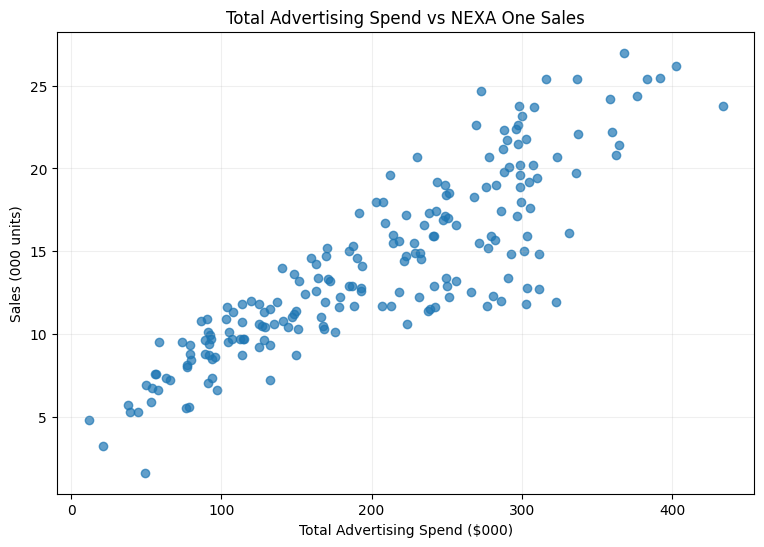

In [ ]:
plt.figure(figsize=(9, 6))

plt.scatter(
    df["total_ads"],
    df["sales"],
    alpha=0.7
)

plt.xlabel("Total Advertising Spend ($000)")
plt.ylabel("Sales (000 units)")
plt.title("Total Advertising Spend vs NEXA One Sales")

plt.grid(alpha=0.2)
plt.show()

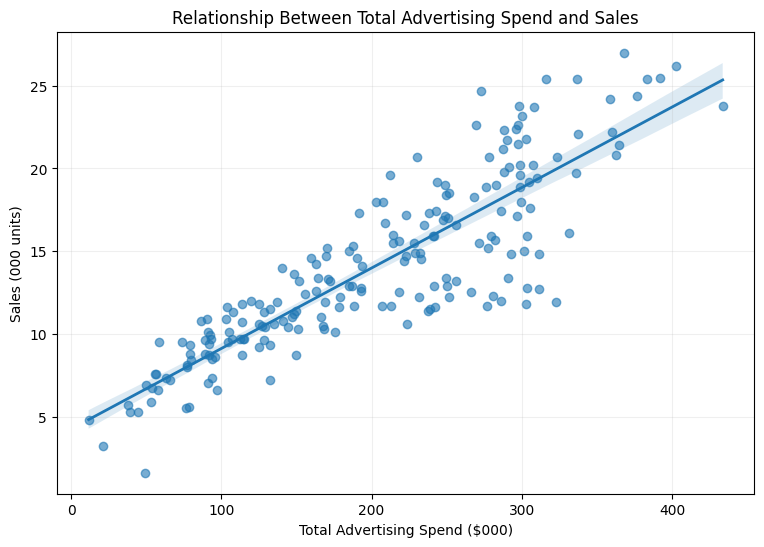

In [ ]:
plt.figure(figsize=(9, 6))

sns.regplot(
    x="total_ads",
    y="sales",
    data=df,
    scatter_kws={"alpha": 0.6},
    line_kws={"linewidth": 2}
)

plt.xlabel("Total Advertising Spend ($000)")
plt.ylabel("Sales (000 units)")
plt.title("Relationship Between Total Advertising Spend and Sales")

plt.grid(alpha=0.2)
plt.show()

## 10. Simple Linear Regression: Total Advertising and Sales

A simple linear regression model is developed to quantify the relationship
between total advertising expenditure and NEXA One sales.

The R-squared value indicates the proportion of observed variation in sales
that is explained by total advertising expenditure in this model.

This is an observational analysis and therefore does not establish causality.

In [ ]:
X_total = sm.add_constant(df["total_ads"])
y = df["sales"]

model_total = sm.OLS(y, X_total).fit()

print(model_total.summary())

                            OLS Regression Results                            
Dep. Variable:                  sales   R-squared:                       0.753
Model:                            OLS   Adj. R-squared:                  0.752
Method:                 Least Squares   F-statistic:                     603.4
Date:                Thu, 24 Sep 2026   Prob (F-statistic):           5.06e-62
Time:                        15:24:34   Log-Likelihood:                -473.88
No. Observations:                 200   AIC:                             951.8
Df Residuals:                     198   BIC:                             958.4
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          4.2430      0.439      9.676      0.0

### Interpretation

The simple linear regression shows a strong positive relationship between total advertising expenditure and sales.

- R-squared ≈ 0.753, meaning approximately 75.3% of the observed variation in sales is explained by total advertising expenditure in this model.
- The coefficient of total advertising expenditure is approximately 0.0487.
- The coefficient is statistically significant (p < 0.001).

The estimated relationship is:

Sales = 4.243 + 0.0487 × Total Advertising Spend

This indicates that higher advertising expenditure is associated with higher observed sales.

However, because the dataset is observational, the regression does not establish that advertising expenditure causes the increase in sales.

## 11. Channel-wise Correlation Analysis

In [ ]:
channel_correlations = df[
    ["tv_ads", "social_media_ads", "print_ads", "sales"]
].corr()["sales"].drop("sales")

print("Correlation of each advertising channel with sales:")
print(channel_correlations.round(4))

Correlation of each advertising channel with sales:
tv_ads              0.7822
social_media_ads    0.5762
print_ads           0.2283
Name: sales, dtype: float64


## 12. Channel Correlation Comparison

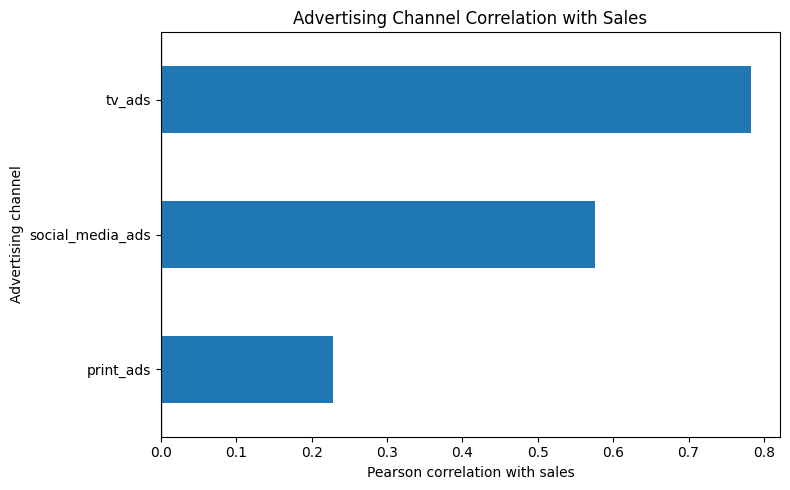

In [ ]:
plt.figure(figsize=(8, 5))

channel_correlations.sort_values().plot(kind="barh")

plt.xlabel("Pearson correlation with sales")
plt.ylabel("Advertising channel")
plt.title("Advertising Channel Correlation with Sales")

plt.axvline(0, linewidth=1)

plt.tight_layout()
plt.show()

## 13. Multiple Linear Regression: Advertising Channels and Sales

In [ ]:
X_channels = df[
    ["tv_ads", "social_media_ads", "print_ads"]
]

X_channels = sm.add_constant(X_channels)

model = sm.OLS(
    df["sales"],
    X_channels
).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  sales   R-squared:                       0.897
Model:                            OLS   Adj. R-squared:                  0.896
Method:                 Least Squares   F-statistic:                     570.3
Date:                Thu, 24 Sep 2026   Prob (F-statistic):           1.58e-96
Time:                        15:30:31   Log-Likelihood:                -386.18
No. Observations:                 200   AIC:                             780.4
Df Residuals:                     196   BIC:                             793.6
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const                2.9389      0.312  

## 14. Regression Coefficients and Statistical Significance

In [ ]:
regression_results = pd.DataFrame({
    "Coefficient": model.params,
    "P-value": model.pvalues,
    "Std. Error": model.bse
})

regression_results.round(4)

,Coefficient,P-value,Std. Error
const,2.9389,0.0000,0.3119
tv_ads,0.0458,0.0000,0.0014
social_media_ads,0.1885,0.0000,0.0086
print_ads,-0.0010,0.8599,0.0059


## 15. Comparing Simple and Multichannel Models

In [ ]:
print("Simple model R²:", round(model_total.rsquared, 4))
print("Multichannel model R²:", round(model.rsquared, 4))
print("Increase in R²:", round(model.rsquared - model_total.rsquared, 4))

Simple model R²: 0.7529
Multichannel model R²: 0.8972
Increase in R²: 0.1443


## 16. Standardized Coefficients

In [ ]:
from sklearn.preprocessing import StandardScaler

X = df[["tv_ads", "social_media_ads", "print_ads"]]
y = df["sales"]

scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y.values.reshape(-1, 1)).ravel()

model_std = sm.OLS(
    y_scaled,
    sm.add_constant(X_scaled)
).fit()

beta = pd.Series(
    model_std.params[1:],
    index=X.columns
)

print("Standardized Beta Coefficients:")
print(beta.round(4))

Standardized Beta Coefficients:
tv_ads              0.7531
social_media_ads    0.5365
print_ads          -0.0043
dtype: float64


## 17. Relative Channel Contribution

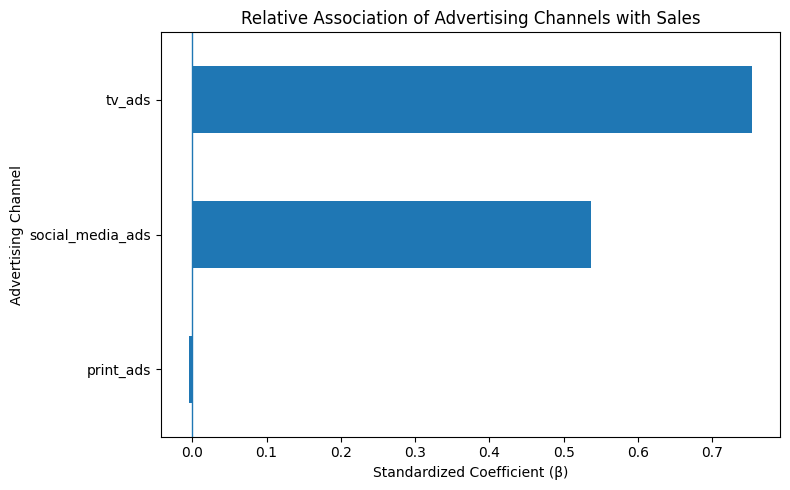

In [ ]:
plt.figure(figsize=(8, 5))

beta.sort_values().plot(kind="barh")

plt.xlabel("Standardized Coefficient (β)")
plt.ylabel("Advertising Channel")
plt.title("Relative Association of Advertising Channels with Sales")

plt.axvline(0, linewidth=1)

plt.tight_layout()
plt.show()

## 18. Actual vs Predicted Sales

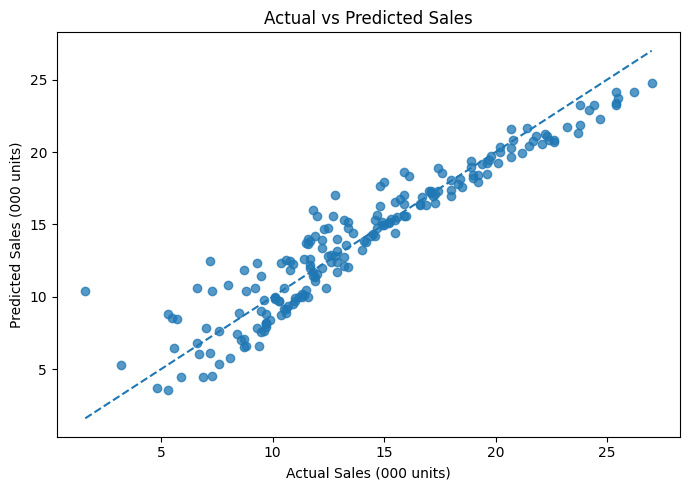

In [ ]:
df["predicted_sales"] = model.predict(
    sm.add_constant(
        df[["tv_ads", "social_media_ads", "print_ads"]]
    )
)

plt.figure(figsize=(7, 5))

plt.scatter(
    df["sales"],
    df["predicted_sales"],
    alpha=0.75
)

min_value = min(
    df["sales"].min(),
    df["predicted_sales"].min()
)

max_value = max(
    df["sales"].max(),
    df["predicted_sales"].max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual Sales (000 units)")
plt.ylabel("Predicted Sales (000 units)")
plt.title("Actual vs Predicted Sales")

plt.tight_layout()
plt.show()

## 19. Residual Analysis

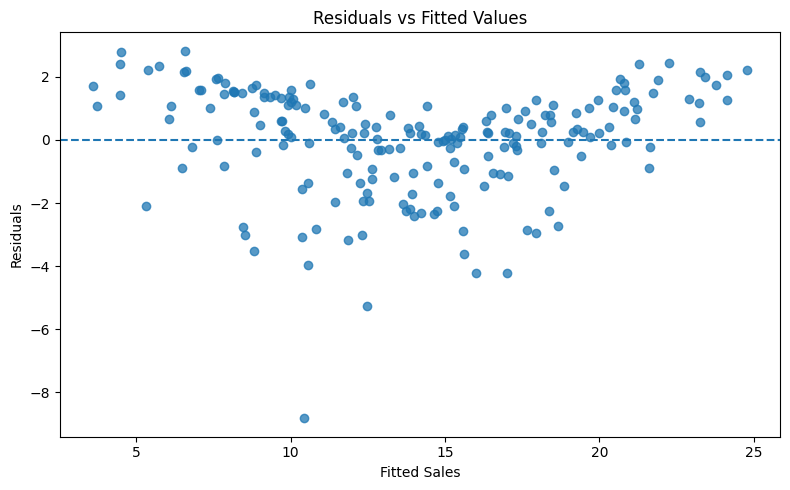

In [ ]:
residuals = model.resid
fitted = model.fittedvalues

plt.figure(figsize=(8, 5))

plt.scatter(
    fitted,
    residuals,
    alpha=0.75
)

plt.axhline(0, linestyle="--")

plt.xlabel("Fitted Sales")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted Values")

plt.tight_layout()
plt.show()

## 20. Observed Advertising Budget Mix

In [ ]:
avg_spend = df[
    ["tv_ads", "social_media_ads", "print_ads"]
].mean()

budget_share = (
    avg_spend / avg_spend.sum() * 100
)

budget_table = pd.DataFrame({
    "Average Spend ($000)": avg_spend.round(2),
    "Budget Share (%)": budget_share.round(2)
})

budget_table

,Average Spend ($000),Budget Share (%)
tv_ads,147.04,73.21
social_media_ads,23.26,11.58
print_ads,30.55,15.21


## 21. Illustrative Budget Reallocation Scenario

In [ ]:
coef = model.params

avg_budget = df[
    ["tv_ads", "social_media_ads", "print_ads"]
].mean()

# Baseline prediction
baseline_prediction = (
    coef["const"]
    + coef["tv_ads"] * avg_budget["tv_ads"]
    + coef["social_media_ads"] * avg_budget["social_media_ads"]
    + coef["print_ads"] * avg_budget["print_ads"]
)

# Reallocate $10,000 from print to social media
scenario_budget = avg_budget.copy()

scenario_budget["print_ads"] -= 10
scenario_budget["social_media_ads"] += 10

# Scenario prediction
scenario_prediction = (
    coef["const"]
    + coef["tv_ads"] * scenario_budget["tv_ads"]
    + coef["social_media_ads"] * scenario_budget["social_media_ads"]
    + coef["print_ads"] * scenario_budget["print_ads"]
)

change = scenario_prediction - baseline_prediction

print("Baseline predicted sales:",
      round(baseline_prediction, 3),
      "thousand units")

print("Scenario predicted sales:",
      round(scenario_prediction, 3),
      "thousand units")

print("Model-implied change:",
      round(change, 3),
      "thousand units")

Baseline predicted sales: 14.022 thousand units
Scenario predicted sales: 15.918 thousand units
Model-implied change: 1.896 thousand units


# 22. Key Findings

### Finding 1 — Advertising spend is strongly associated with sales

Total advertising expenditure has a strong positive association with sales (r ≈ 0.868), while the simple regression explains approximately 75.3% of observed sales variation.

### Finding 2 — Advertising mix adds explanatory power

The multichannel model explains approximately 89.7% of observed sales variation, compared with 75.3% for the total-spend model. This represents an improvement of 14.43 percentage points in R².

### Finding 3 — TV shows the strongest association

TV has the strongest simple correlation with sales (r ≈ 0.782) and the largest standardized coefficient (β ≈ 0.753).

### Finding 4 — Social media shows meaningful incremental association

Social media has a positive correlation with sales (r ≈ 0.576), a standardized coefficient of approximately 0.537, and a statistically significant coefficient in the multichannel model.

### Finding 5 — Print has limited incremental explanatory power

Print has a weaker simple correlation with sales (r ≈ 0.228), a near-zero standardized coefficient (β ≈ -0.004), and is not statistically significant in the multichannel model (p ≈ 0.860).

# 23. External Market Research

## Consumer Purchase Factors

Independent research indicates that important factors in wireless audio purchasing include **sound quality, battery life, comfort, active noise cancellation (ANC), and durability**.

### Marketing implication

NEXA should connect advertising messages directly to these customer-valued product attributes rather than relying only on broad product awareness.

---

## Consumer Spending Environment

Recent consumer technology research indicates continued **price sensitivity** and growing emphasis on **value for money**.

### Marketing implication

NEXA should communicate value through performance, durability, convenience and product benefits rather than relying exclusively on discounts.

---

## Technology and Category Trends

The wireless audio category continues to evolve, with emerging audio formats gaining attention.

### Marketing implication

NEXA should monitor changing consumer preferences and adapt product positioning and advertising messages accordingly.

---

## Supply-Chain Environment

The electronics industry continues to face component pricing and supply uncertainty.

### Marketing implication

Advertising intensity should be coordinated with **product availability, pricing decisions and inventory conditions** to avoid promoting products that face supply constraints.

# 24. Business Implications

## 1. TV remains strategically important

TV has the strongest observed relationship with sales and currently represents 73.21% of the observed advertising budget.

The evidence supports maintaining TV as a core reach channel while continuing to validate its effectiveness.

## 2. Social media represents an experimentation opportunity

Social media shows a meaningful positive association with sales while receiving only 11.58% of the observed advertising budget.

NEXA can use social media for targeted campaigns, creative testing and audience-level experimentation.

## 3. Print should be evaluated carefully

Print represents approximately 15.21% of the observed advertising budget but shows substantially weaker association with sales.

Rather than eliminating print immediately, NEXA should test controlled reallocations toward social media.

## 4. Product messaging should reflect consumer priorities

Advertising should emphasize customer-relevant product attributes such as:

- Sound quality
- Active noise cancellation
- Battery life
- Comfort
- Durability
- Value for money

## 5. Marketing should be coordinated with market conditions

Consumer price sensitivity, technology shifts, product availability and supply-chain conditions should be considered when setting advertising intensity and product messaging.

# 25. Recommended Strategy

## Priority 1 — Maintain TV as a Core Reach Channel

TV shows the strongest observed association with sales and should remain an important component of NEXA's media mix.

The recommendation is to maintain its strategic role while continuing to validate its effectiveness through market-level testing.

---

## Priority 2 — Test a Controlled Print-to-Social Reallocation

Pilot shifting a portion of print expenditure toward social media while keeping total advertising expenditure constant.

The illustrative $10,000 reallocation scenario produces a model-implied sales increase of approximately 1.896 thousand units.

This is a model-implied scenario, not a causal forecast, and should therefore be validated through controlled experiments.

---

## Priority 3 — Build Campaigns Around Customer Purchase Drivers

Emphasize:

- Sound quality
- Active noise cancellation
- Battery life
- Comfort
- Durability
- Value for money

---

## Priority 4 — Use a Test → Measure → Compare → Scale Framework

Use future campaigns to validate whether the relationships observed in the dataset translate into incremental sales.

**Pilot → Measure → Compare → Scale**

---

## Priority 5 — Coordinate Marketing With Market Conditions

Align campaign intensity with:

- Product availability
- Consumer price sensitivity
- Emerging audio formats
- Pricing decisions
- Supply-chain conditions

# 26. Executive Conclusion

The analysis identifies three central implications for NEXA One:

### 01 — Advertising Matters

Total advertising expenditure has a strong positive association with sales, with a Pearson correlation of approximately 0.868.

### 02 — The Advertising Mix Matters

The multichannel model explains approximately 89.7% of observed sales variation, compared with 75.3% for the total-spend model.

TV and social media show substantially stronger associations with sales than print within the observed dataset.

### 03 — Validation Matters

The observational analysis should guide where NEXA experiments rather than being treated as proof of causal advertising returns.

### Strategic Direction

Maintain TV as a core reach channel, test a controlled reallocation from print toward social media, and strengthen product-focused messaging around sound quality, ANC, battery life, comfort and value.

### Decision Framework

**Pilot → Measure → Compare → Scale**

*All regression findings are based on observational market-level data and should not be interpreted as causal effects.*

# 27. References

1. Qualcomm — State of Sound 2025  
   https://www.qualcomm.com/audio/state-of-sound-2025

2. Which? — How we test headphones, 2026  
   https://www.which.co.uk/reviews/headphones/article/how-we-test-headphones-a6sQ96U4kQF2

3. Omdia — OWS shipments grow 12% as TWS market remains broadly flat in Q2 2026  
   https://omdia.tech.informa.com/pr/2026/sep/ows-shipments-grow-12percent-as-tws-market-remains-broadly-flat-in-2q26

4. NIQ — Consumer Tech Trends 2027  
   https://nielseniq.com/global/en/insights/report/2026/consumer-tech-trends-2027/

5. S&P Global — Electronics Supply Chain Outlook, 2026  
   https://www.spglobal.com/market-intelligence/en/news-insights/research/2026/03/electronics-supply-chain-outlook